<a href="https://colab.research.google.com/github/mouryadipesh1606-oss/app/blob/main/tree_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
pd.set_option('display.max_rows', 100)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
%load_ext rpy2.ipython

In [15]:
df = pd.read_csv('tree.txt', sep=r'\s+')
df

,ID,yr,cm,annualprec,summerpdsi,wintertemp
1,290,1998,4.0,1.7650,-0.7950,5.633333
2,290,2002,4.4,1.8056,-1.0550,5.400000
3,290,2004,4.8,1.8532,-0.7950,5.100000
4,290,2006,5.1,1.4533,-2.0425,5.666667
5,290,2008,5.3,1.5392,-2.4700,4.833333
...,...,...,...,...,...,...
507,729,2006,26.4,1.4533,-2.0425,5.666667
508,729,2008,26.4,1.5392,-2.4700,4.833333
509,729,2010,26.5,1.4914,-1.5675,2.033333
510,729,2011,26.3,2.0694,-0.3875,5.133333


In [17]:
df['ID'].nunique()

88

In [18]:
df['yr'].value_counts().sort_index()

,count
yr,
1998,67
2002,68
2004,69
2006,64
2007,15
2008,77
2010,77
2011,74


In [21]:
df.sort_values(by=['yr','ID'])
df['cm_growth'] = df.groupby(['ID'])['cm'].pct_change()
df

,ID,yr,cm,annualprec,summerpdsi,wintertemp,cm_growth
1,290,1998,4.0,1.7650,-0.7950,5.633333,NaN
2,290,2002,4.4,1.8056,-1.0550,5.400000,0.100000
3,290,2004,4.8,1.8532,-0.7950,5.100000,0.090909
4,290,2006,5.1,1.4533,-2.0425,5.666667,0.062500
5,290,2008,5.3,1.5392,-2.4700,4.833333,0.039216
...,...,...,...,...,...,...,...
507,729,2006,26.4,1.4533,-2.0425,5.666667,0.000000
508,729,2008,26.4,1.5392,-2.4700,4.833333,0.000000
509,729,2010,26.5,1.4914,-1.5675,2.033333,0.003788
510,729,2011,26.3,2.0694,-0.3875,5.133333,-0.007547


In [22]:
plt.rcParams.update({'font.size':15})
plt.rcParams['figure.figsize']=15,10

In [23]:
df.corr()

,ID,yr,cm,annualprec,summerpdsi,wintertemp,cm_growth
ID,1.000000,0.165412,-0.159407,-0.071986,-0.096677,-0.062711,0.044468
yr,0.165412,1.000000,-0.027707,-0.092939,-0.226462,-0.525235,-0.121801
cm,-0.159407,-0.027707,1.000000,0.070308,0.078491,-0.005269,-0.183631
annualprec,-0.071986,-0.092939,0.070308,1.000000,0.896033,0.314697,-0.017532
summerpdsi,-0.096677,-0.226462,0.078491,0.896033,1.000000,0.130760,0.029375
wintertemp,-0.062711,-0.525235,-0.005269,0.314697,0.130760,1.000000,-0.054414
cm_growth,0.044468,-0.121801,-0.183631,-0.017532,0.029375,-0.054414,1.000000


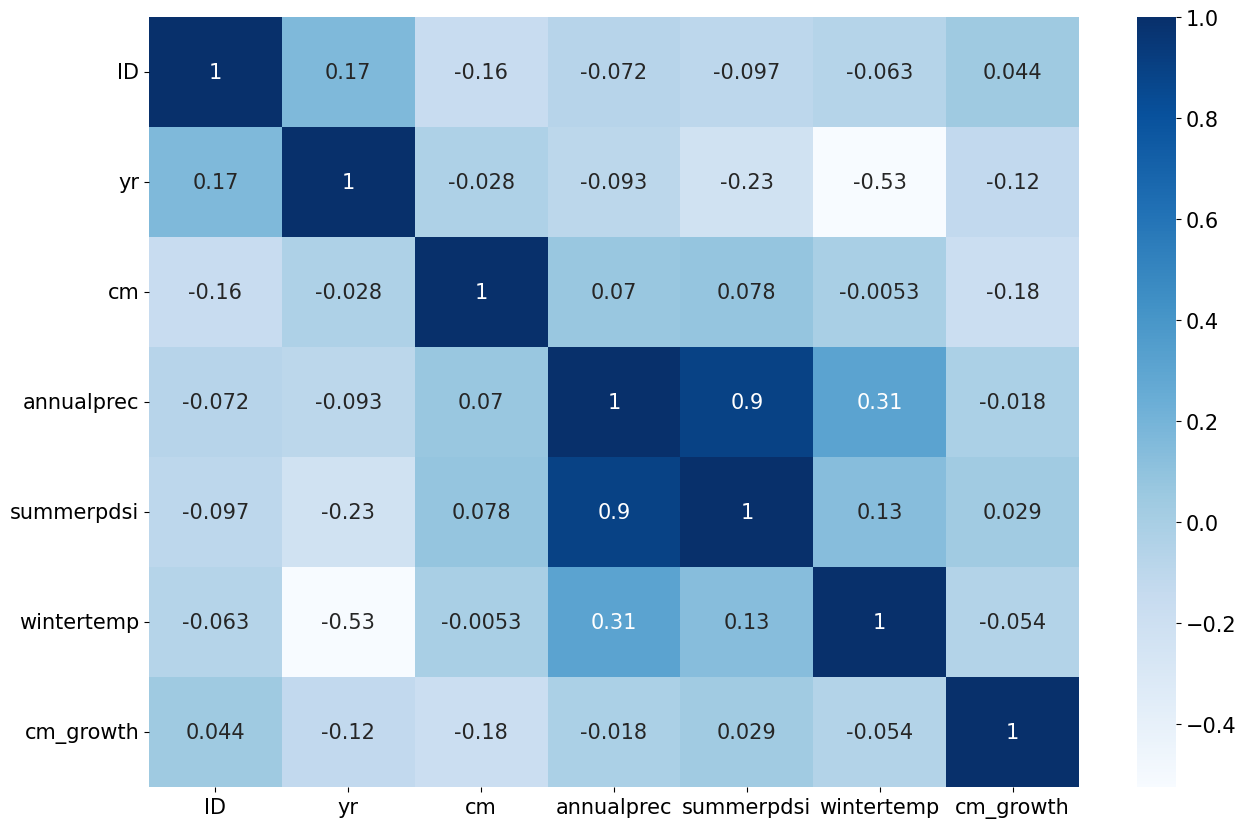

In [24]:
corr_matrix = df.corr()
fig1= sns.heatmap(corr_matrix, annot=True, cmap='Blues')

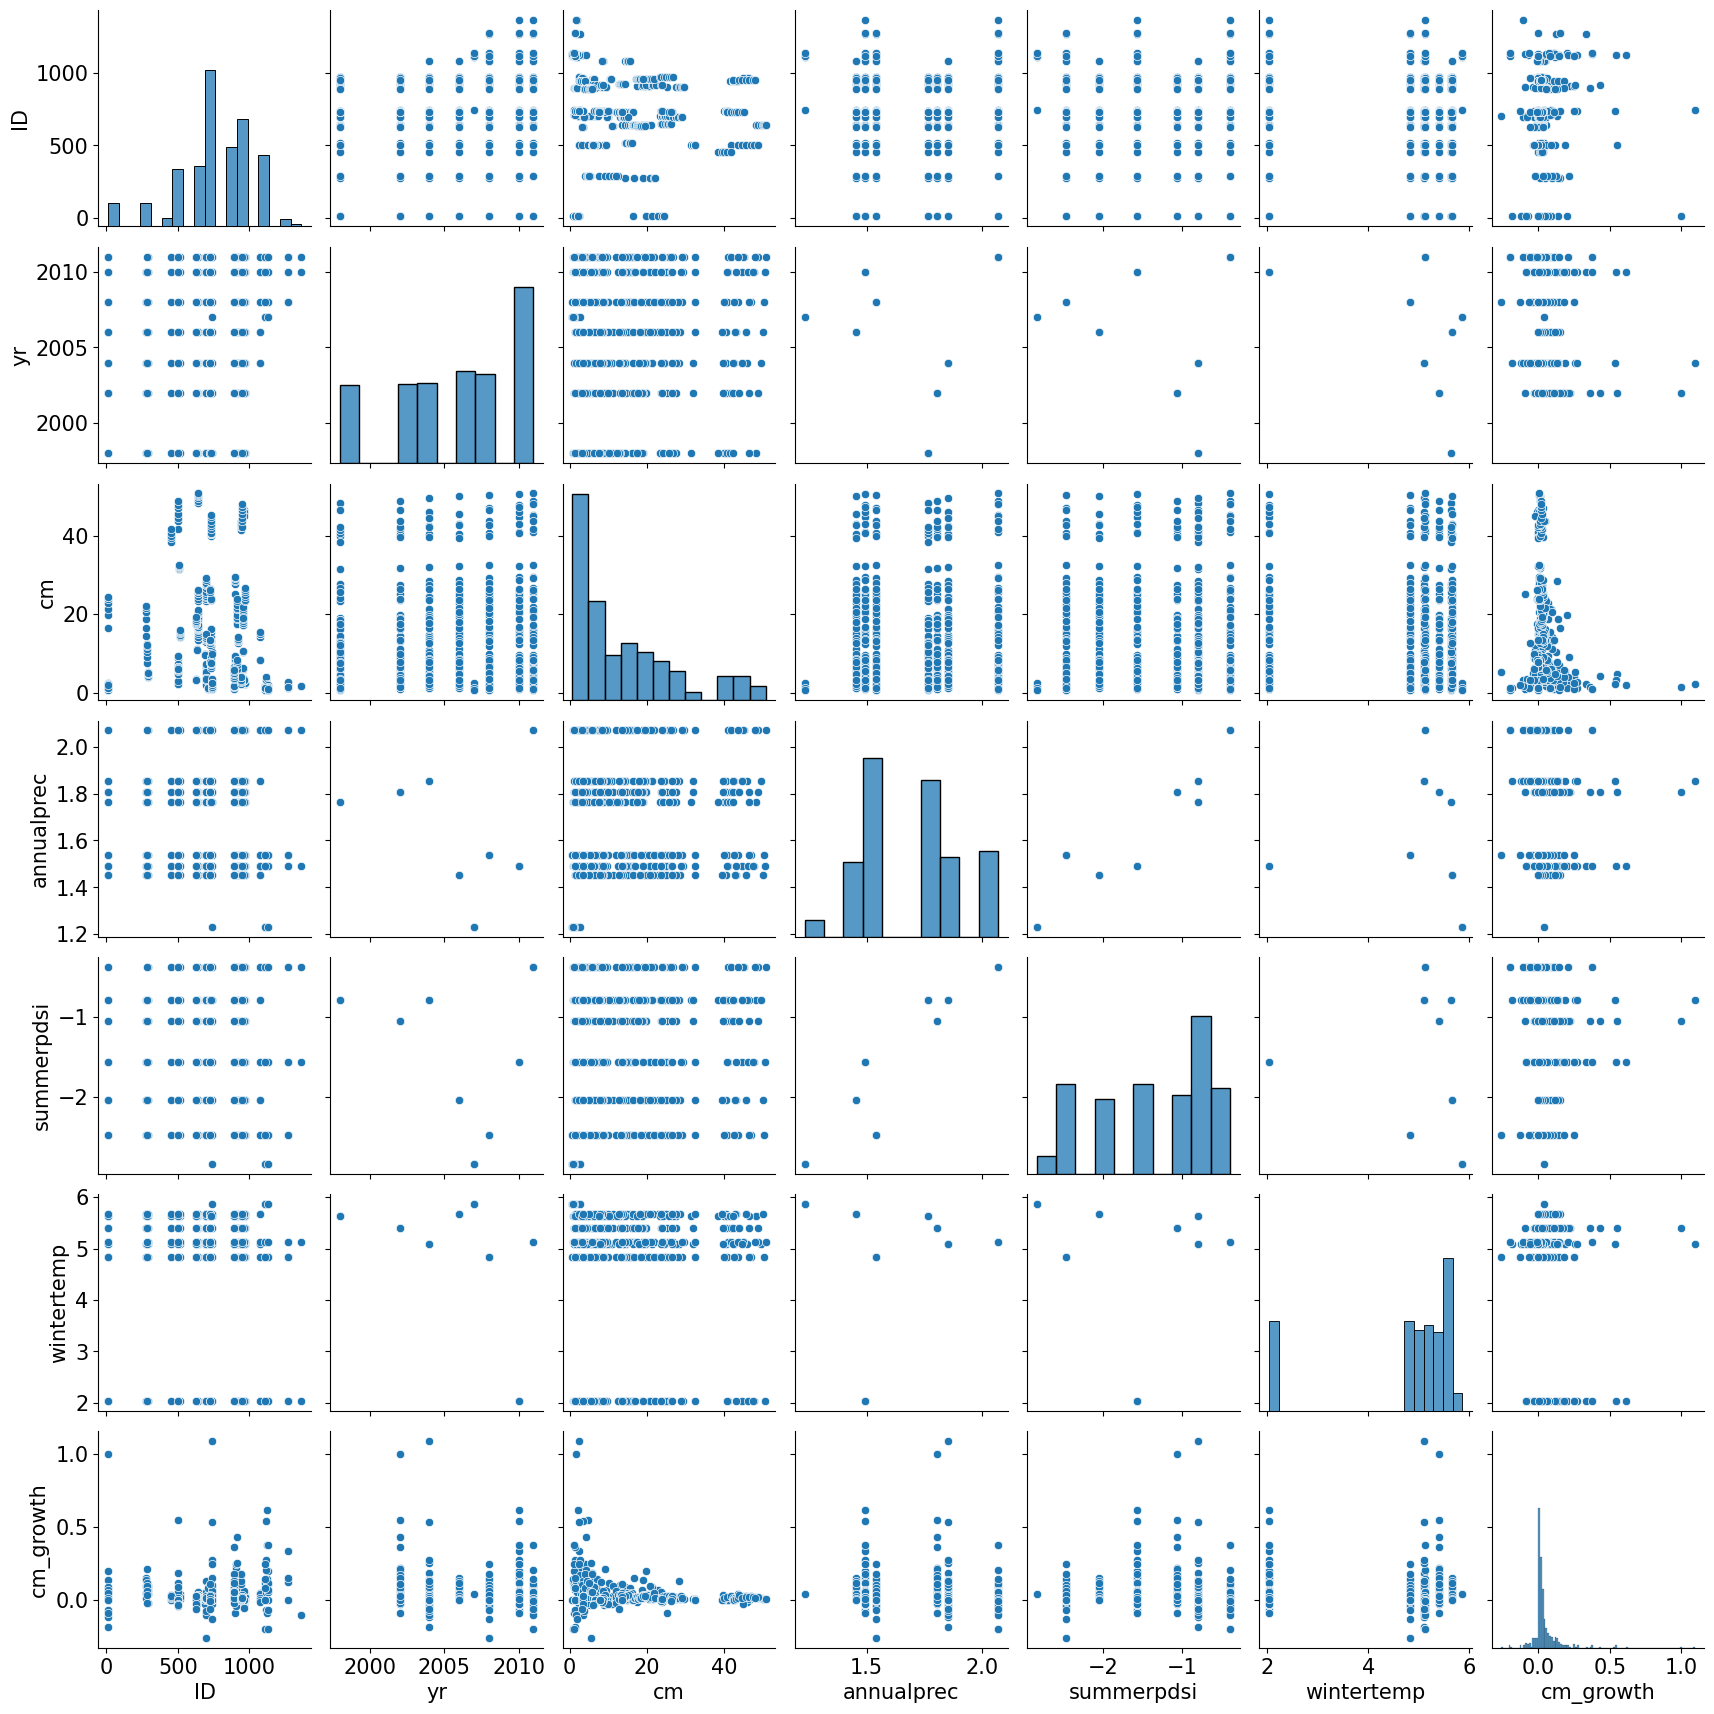

In [25]:
fig2 = sns.pairplot(df);

Text(0.5, 1.0, 'Tree by Diameter in Centimeters')

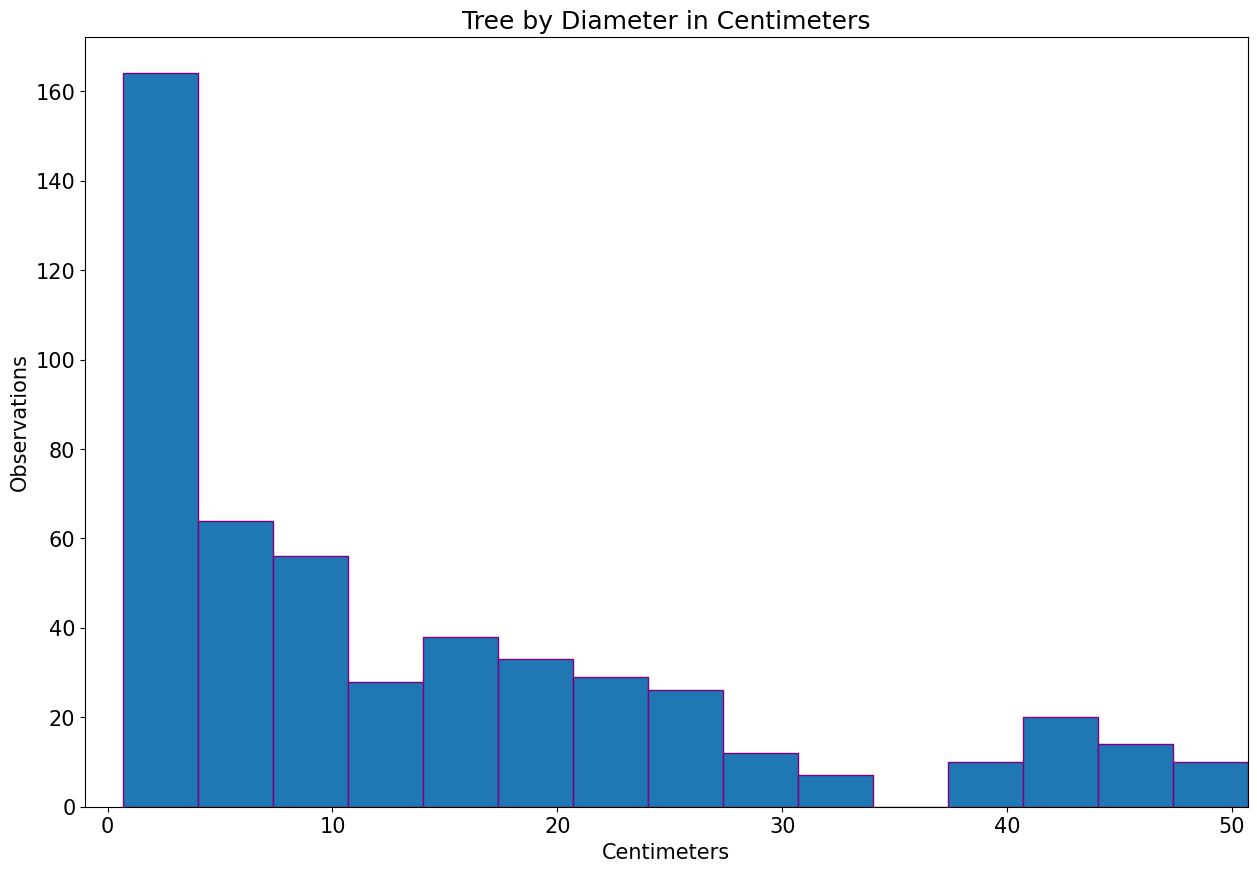

In [28]:
plt.hist(x = df['cm'], lw = 2.5, edgecolor = 'purple', bins=15)
plt.xlim([-1, round(df['cm'].max(),+1)])
plt.xlabel('Centimeters')
plt.ylabel('Observations')
plt.title('Tree by Diameter in Centimeters')

In [29]:
df['cm'].median()

8.7

In [32]:
conditions = [
    (df['cm'] <= 2.54), # Seedlings
    (df['cm'] > 2.54) & (df['cm'] <= 12.45), # Saplings
    (df['cm'] > 12.45) & (df['cm'] <= 22.6), # Poletimbers
    (df['cm'] > 22.6) # Sawtimbers
]
values = ['Seedlings', 'Saplings', 'Poletimbers', 'Sawtimbers']
df['Tree_Size_Category'] = np.select(conditions, values, default='Unknown')
df

,ID,yr,cm,annualprec,summerpdsi,wintertemp,cm_growth,Tree_Size_Category
1,290,1998,4.0,1.7650,-0.7950,5.633333,NaN,Saplings
2,290,2002,4.4,1.8056,-1.0550,5.400000,0.100000,Saplings
3,290,2004,4.8,1.8532,-0.7950,5.100000,0.090909,Saplings
4,290,2006,5.1,1.4533,-2.0425,5.666667,0.062500,Saplings
5,290,2008,5.3,1.5392,-2.4700,4.833333,0.039216,Saplings
...,...,...,...,...,...,...,...,...
507,729,2006,26.4,1.4533,-2.0425,5.666667,0.000000,Sawtimbers
508,729,2008,26.4,1.5392,-2.4700,4.833333,0.000000,Sawtimbers
509,729,2010,26.5,1.4914,-1.5675,2.033333,0.003788,Sawtimbers
510,729,2011,26.3,2.0694,-0.3875,5.133333,-0.007547,Sawtimbers


In [33]:
px.scatter(data_frame=df, x = 'summerpdsi', y = 'cm' , color = 'Tree_Size_Category', trendline='ols')